In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [20]:
df_air = pd.read_csv("ContinuousAirQuality1993-2024.csv")

df_air.head()
df_air.columns
df_air.info()
df_air["DATE_TIME"].head(10)
df_air[df_air["DATE_TIME"].str.contains("24:00", na=False)].head() #some date time values are in 24:00 format which is not recognized by pandas as a valid time format. 
#We need to convert these to 00:00 of the next day.
df_air["DATE_TIME"] = df_air["DATE_TIME"].str.replace("24:00", "00:00", regex=False)

df_air["DATE_TIME"] = pd.to_datetime(df_air["DATE_TIME"], dayfirst=True, errors="coerce") #coerce remaining errors, due to 1.6 million datapoints

#Extract year, month and hour from the date time column for further analysis.
df_air["Year"] = df_air["DATE_TIME"].dt.year
df_air["Month"] = df_air["DATE_TIME"].dt.month
df_air["Hour"] = df_air["DATE_TIME"].dt.hour #Key point here: data is available hourly





/var/folders/6n/8_lfx6j975gckgr9j3ny8bdw0000gn/T/ipykernel_89942/3766742486.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_air = pd.read_csv("ContinuousAirQuality1993-2024.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1677923 entries, 0 to 1677922
Data columns (total 10 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   SITE_ID    1677923 non-null  int64  
 1   LOCATION   1677923 non-null  object 
 2   EASTING    1677923 non-null  int64  
 3   NORTHING   1677923 non-null  int64  
 4   DATE_TIME  1677923 non-null  object 
 5   NO         1529607 non-null  float64
 6   NOX        1523271 non-null  float64
 7   NO2        1520486 non-null  float64
 8   PM2_5      162690 non-null   object 
 9   PM10       358192 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 128.0+ MB


In [ ]:
df_air.isnull().sum() #checking for missing data points

df_air.duplicated(subset=["SITE_ID","DATE_TIME"]).sum() #checking for duplicate rows based on site id and date time, as these should be unique for each measurement, returned a high number of duplicates, 
#likely due to the errors in date time values that were coerced to NaT.

df_air = df_air.dropna(subset=["DATE_TIME"]) #dropping rows with invalid date time values
df_air.duplicated(subset=["SITE_ID","DATE_TIME"]).sum()

df_air["LOCATION"].nunique()
df_air["SITE_ID"].nunique()
#confirmation of data structure:
#Time: hourly (1993 - 2024)
#Space: 19 sites
#Observations: ~1.6 million



19

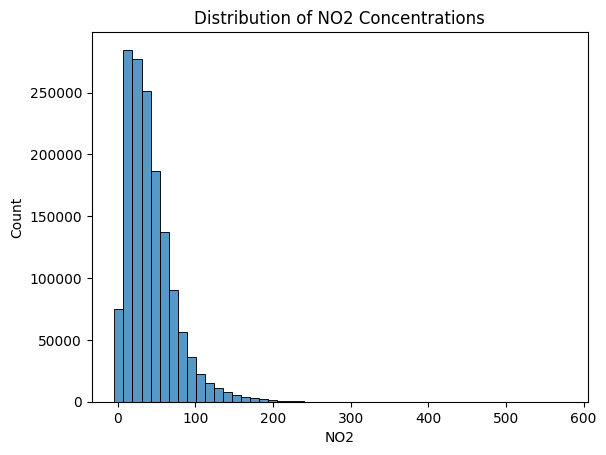

In [33]:
sns.histplot(df_air["NO2"].dropna(), bins=50)
plt.title("Distribution of NO2 Concentrations")
plt.show()


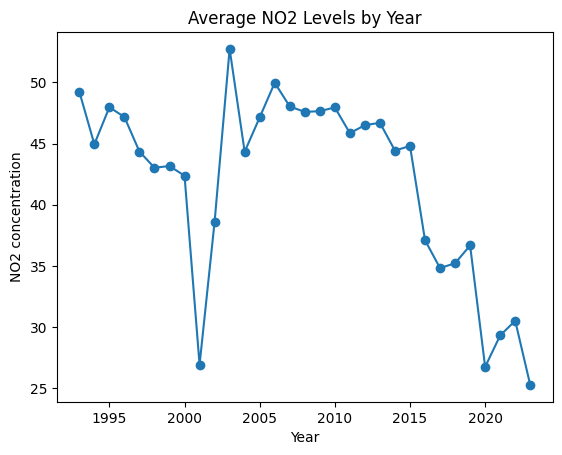

In [ ]:
df_air.groupby("Year")["NO2"].mean().plot(marker="o")
plt.title("Average NO2 Levels by Year")
plt.ylabel("NO2 concentration")
plt.show()

#Interpretation: downward trend, correlates with increased environmental regulations.

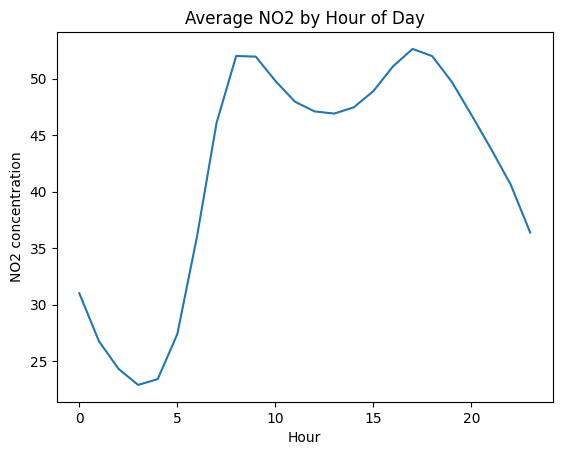

In [ ]:
df_air.groupby("Hour")["NO2"].mean().plot()
plt.title("Average NO2 by Hour of Day")
plt.ylabel("NO2 concentration")
plt.show()
#Interpretation: higher NO2 levels during morning and evening rush hours, indicating traffic as a major source of pollution.


/var/folders/6n/8_lfx6j975gckgr9j3ny8bdw0000gn/T/ipykernel_89942/898391855.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_air.groupby(["Hour","period"])["NO2"].mean().unstack().plot(figsize=(10,6))


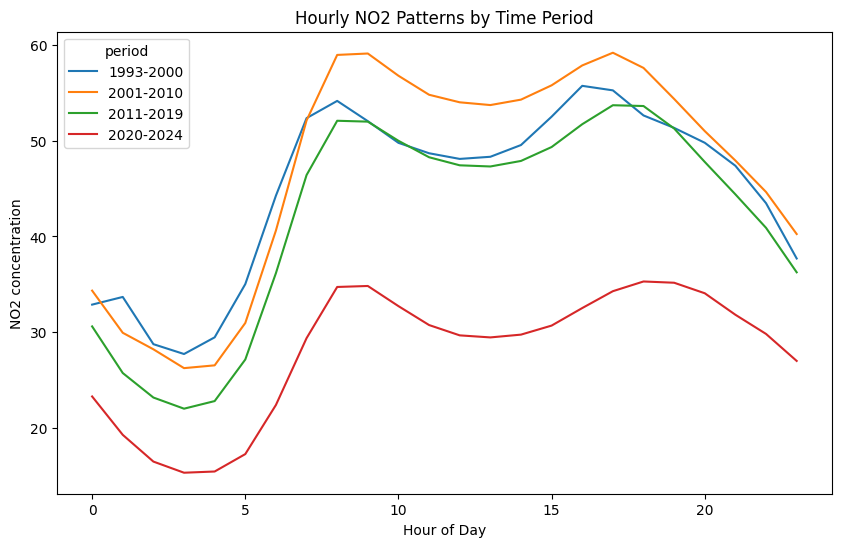

In [38]:
df_air["period"] = pd.cut(
    df_air["Year"],
    bins=[1992,2000,2010,2019,2024],
    labels=["1993-2000","2001-2010","2011-2019","2020-2024"]
)

df_air.groupby(["Hour","period"])["NO2"].mean().unstack().plot(figsize=(10,6))

plt.title("Hourly NO2 Patterns by Time Period")
plt.xlabel("Hour of Day")
plt.ylabel("NO2 concentration")

plt.show()


